# Supervised Learning Course Assignment 2

| Name | ID |
|------|----|
|  Mohamed Beshr Al Sofi | 20230717  |
|  Ayman Sayed Abd-Elmonem | 20230081  |
|  Sadek Amin | 20220725  |


In [ ]:
# ── Setup & Data Loading ──────────────────────────────────────────────────
# Import required libraries and load the CIFAR-10 dataset.
# The dataset is split into 40 000 training, 10 000 validation,
# and 10 000 test images (32×32 RGB).

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [ ]:
# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi':      120,
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


In [ ]:
# ── Helper Functions ──────────────────────────────────────────────────────
# train_and_evaluate() compiles, trains, and evaluates a Keras model, then
# reports test accuracy, test loss, and total training time.
# plot_curves() draws training / validation metric curves for comparison.

def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te, epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()

    # Determine loss type to handle labels correctly
    is_sparse = model.loss == 'sparse_categorical_crossentropy'
    y_tr_proc = y_tr if is_sparse else to_categorical(y_tr, 10)
    y_v_proc = y_v if is_sparse else to_categorical(y_v, 10)
    y_te_proc = y_te if is_sparse else to_categorical(y_te, 10)

    history = model.fit(x_tr, y_tr_proc,
                        validation_data=(x_v, y_v_proc),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0
                        )

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, y_te_proc, verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def BaselineCNN():
  model = models.Sequential([
      layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
      layers.MaxPooling2D((2, 2)),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [ ]:
# Min-Max Scaler
from sklearn.preprocessing import MinMaxScaler
minMax = MinMaxScaler()

x_train_minMax = minMax.fit_transform(x_train.reshape(-1, 32*32*3))
x_val_minMax = minMax.transform(x_val.reshape(-1, 32*32*3))
x_test_minMax = minMax.transform(x_test.reshape(-1, 32*32*3))

# Reshaping
x_train_minMax = x_train_minMax.reshape(-1, 32, 32, 3)
x_val_minMax = x_val_minMax.reshape(-1, 32, 32, 3)
x_test_minMax = x_test_minMax.reshape(-1, 32, 32, 3)

In [ ]:
# Standrdiaztion
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()

x_train_standard = standard.fit_transform(x_train.reshape(-1, 32*32*3))
x_val_standard = standard.transform(x_val.reshape(-1, 32*32*3))
x_test_standard = standard.transform(x_test.reshape(-1, 32*32*3))

# Reshaping
x_train_standard = x_train_standard.reshape(-1, 32, 32, 3)
x_val_standard = x_val_standard.reshape(-1, 32, 32, 3)
x_test_standard = x_test_standard.reshape(-1, 32, 32, 3)

In [ ]:
# Training normal data
model = BaselineCNN()
history, test_acc, test_loss, elapsed = train_and_evaluate(model, x_train, y_train, x_val, y_val, x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5467 | Test Loss: 2.9020 | Time:49.1s


In [ ]:
# Training minMax scaled data
model = BaselineCNN()
history_minMax, test_acc_minMax, test_loss_minMax, elapsed_minMax = train_and_evaluate(model, x_train_minMax, y_train, x_val_minMax, y_val, x_test_minMax, y_test)

Test Acc: 0.6621 | Test Loss: 1.3798 | Time:48.5s


In [ ]:
# Training standardized data
model = BaselineCNN()
history_standard, test_acc_standard, test_loss_standard, elapsed_standard = train_and_evaluate(model, x_train_standard, y_train, x_val_standard, y_val, x_test_standard, y_test)

Test Acc: 0.6737 | Test Loss: 2.0812 | Time:48.9s


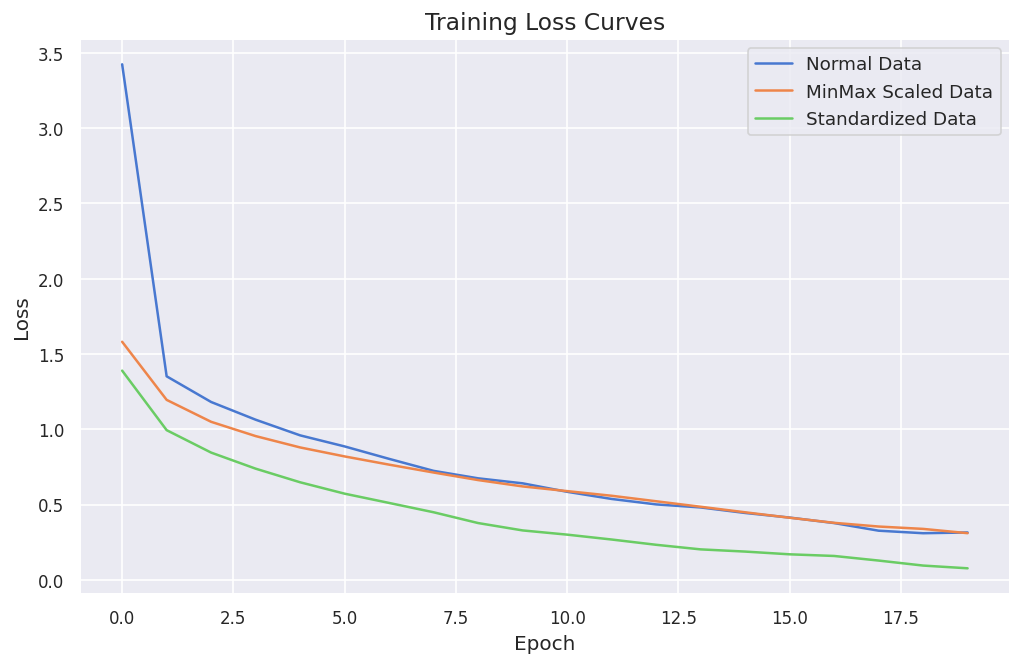

In [ ]:
# Plots
histories = [history, history_minMax, history_standard]
labels = ['Normal Data', 'MinMax Scaled Data', 'Standardized Data']

# Loss Plots
plot_curves(histories, labels, metric='loss', title='Training Loss Curves', ylabel='Loss')



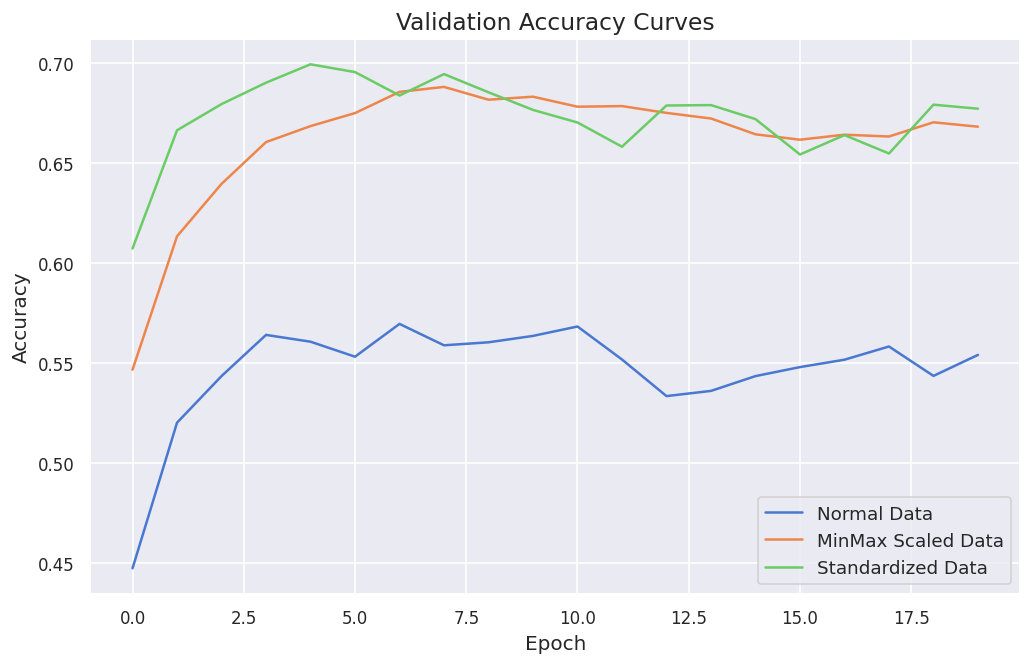

In [ ]:
# Accuracy plots
plot_curves(histories, labels, title='Validation Accuracy Curves', ylabel='Accuracy')

In [ ]:
# Generating table
import pandas as pd
Data = {"Train Acc": [history.history['accuracy'][-1], history_minMax.history['accuracy'][-1], history_standard.history['accuracy'][-1]],
        "Val Acc" : [history.history['val_accuracy'][-1], history_minMax.history['val_accuracy'][-1], history_standard.history['val_accuracy'][-1]],
        "Test Acc": [test_acc, test_acc_minMax, test_acc_standard],
        "Loss @ epoch 1": [history.history['loss'][0], history_minMax.history['loss'][0], history_standard.history['loss'][0]]}
index = ["None [0-255]", "MinMax [0,1]", "Standardized"]
df = pd.DataFrame(Data, index=index)
df

,Train Acc,Val Acc,Test Acc,Loss @ epoch 1
None [0-255],0.896400,0.5541,0.5467,3.424636
"MinMax [0,1]",0.894075,0.6682,0.6621,1.581232
Standardized,0.975075,0.6772,0.6737,1.389482


In [ ]:
def Augmented():
  datagen = tf.keras.preprocessing.image.ImageDataGenerator(
  rotation_range=15,
  width_shift_range=0.1,
  height_shift_range=0.1,
  horizontal_flip=True,
  zoom_range=0.1
  )
  datagen.fit(x_train_standard)
  return datagen

In [ ]:
# Training with augmented data
model_aug = BaselineCNN()
datagen = Augmented()
augmented_train_generator = datagen.flow(x_train_standard, to_categorical(y_train, 10), batch_size=128)

start_aug = time.time()
history_aug = model_aug.fit(augmented_train_generator,
                            validation_data=(x_val_standard, to_categorical(y_val, 10)),
                            epochs=40,
                            verbose=0)
elapsed_aug = time.time() - start_aug

test_loss_aug, test_acc_aug = model_aug.evaluate(x_test_standard, to_categorical(y_test, 10), verbose=0)
print(f"Test Acc: {test_acc_aug:.4f} | Test Loss: {test_loss_aug:.4f} | Time: {elapsed_aug:.1f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.7734 | Test Loss: 0.7115 | Time: 1000.8s


In [ ]:
# Training with standardized data (no augmented)
model = BaselineCNN()
history_non_aug, test_acc_non_aug, test_loss_non_aug, elapsed_non_aug = train_and_evaluate(model, x_train_standard, y_train, x_val_standard, y_val, x_test_standard, y_test, epochs=40)

Test Acc: 0.6764 | Test Loss: 3.1301 | Time:92.8s


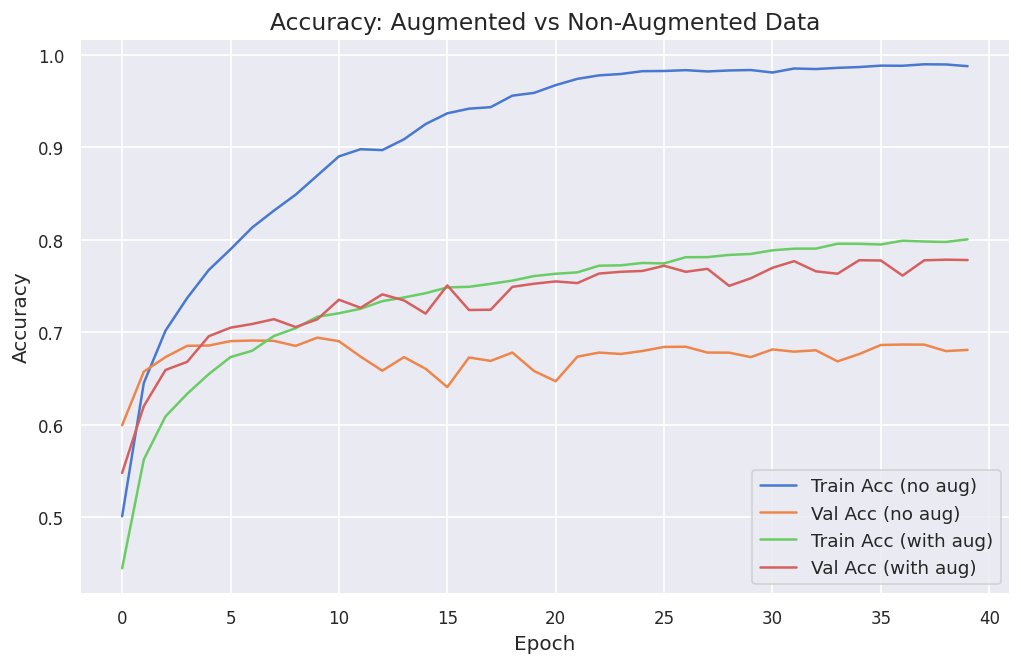

In [ ]:
# Plotting 4 curves
plt.figure(figsize=(10, 6))
plt.plot(history_non_aug.history['accuracy'], label='Train Acc (no aug)')
plt.plot(history_non_aug.history['val_accuracy'], label='Val Acc (no aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (with aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (with aug)')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy: Augmented vs Non-Augmented Data')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Non-augmented gap
gap_non_aug = history_non_aug.history['accuracy'][39] - history_non_aug.history['val_accuracy'][39]

# Augmented gap
gap_aug = history_aug.history['accuracy'][39] - history_aug.history['val_accuracy'][39]

print(f"Non-Augmented gap at epoch 40: {gap_non_aug:.4f}")
print(f"Augmented gap at epoch 40: {gap_aug:.4f}")
if(gap_non_aug < gap_aug):
  print("Non-Augmented is better")
else:
  print("Augmented is better")

Non-Augmented gap at epoch 40: 0.3066
Augmented gap at epoch 40: 0.0224
Augmented is better


## **Task2 -> build model**

### part A

In [ ]:
# Imports
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout

In [ ]:
# ── Part A – Width Experiment ─────────────────────────────────────────────
# Build and train three CNN variants with increasing filter widths
# (small: 8/16, medium: 16/32, large: 24/48 filters per block).
# Each model has two Conv blocks followed by a Flatten + Dense head.


partA_models = []
for i in range(1,4):
    model = Sequential([
        Conv2D(filters= i * 8, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= i * 8, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= i * 8 * 2, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= i * 8 * 2, kernel_size=3, padding = 'same', activation= 'relu'),

        Flatten(),
        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')
    ])

    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )
    print(model.summary())
    model.fit(x_train,y_train,epochs=20,batch_size=128,validation_data=(x_val,y_val))
    partA_models.append(model)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,055,698 (4.03 MB)

 Trainable params: 1,055,698 (4.03 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_70 (Conv2D)              │ (None, 32, 32, 24)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 32, 32, 24)     │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 16, 16, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 16, 16, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,185,634 (12.15 MB)

 Trainable params: 3,185,634 (12.15 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3628 - loss: 3.3876 - val_accuracy: 0.4527 - val_loss: 1.5432
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5050 - loss: 1.3726 - val_accuracy: 0.4904 - val_loss: 1.4378
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5906 - loss: 1.1554 - val_accuracy: 0.5044 - val_loss: 1.3970
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6497 - loss: 0.9908 - val_accuracy: 0.4978 - val_loss: 1.4725
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7027 - loss: 0.8408 - val_accuracy: 0.4961 - val_loss: 1.5961
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7678 - loss: 0.6612 - val_accuracy: 0.4915 - val_loss: 1.9092
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8112 - loss: 0.5393 - val_accuracy: 0.5004 - val_loss: 2.1954
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8451 - loss: 0.4486 - va

In [ ]:
# ── Part A – Evaluate Accuracy ───────────────────────────────────────────
# Run inference on the test set for each Part-A model and record accuracy.

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracy_scores = []
name_models = ['small','medium','large']
for i,model in enumerate(partA_models):
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


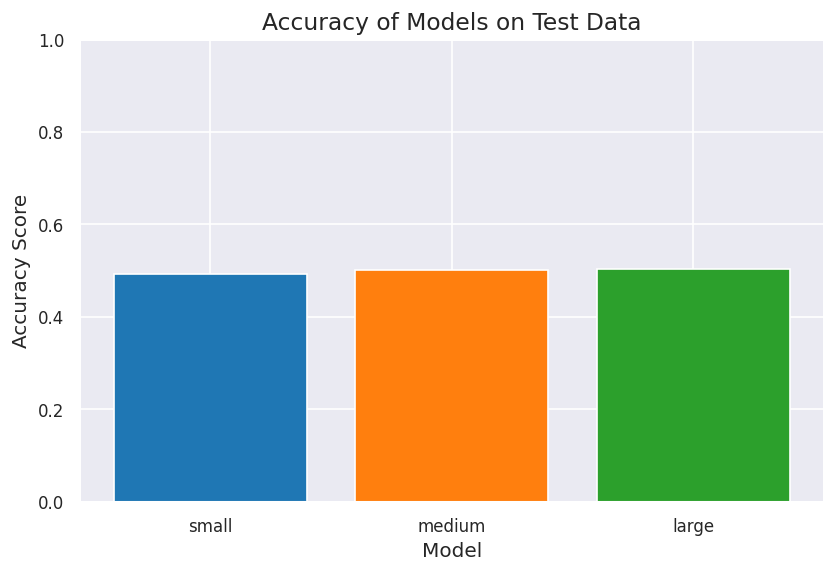

In [ ]:
# ── Part A – Visualise Results ───────────────────────────────────────────
# Plot a bar chart comparing the test accuracy of the three CNN widths.

# Create the bar plot with different colors
plt.figure(figsize=(8, 5))
plt.bar(name_models, accuracy_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Accuracy of Models on Test Data')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.show()

### Part C

In [ ]:
# ── Part C – Depth & Pooling Experiment ──────────────────────────────────
# Define three CNN architectures that explore increasing depth and the
# effect of Global Average Pooling (GAP) as a replacement for Flatten.
#   Model 1: 2 Conv blocks + Flatten (baseline)
#   Model 2: 3 Conv blocks + 1× GAP
#   Model 3: 4 Conv blocks + 2× GAP

from tensorflow.keras.layers import GlobalAveragePooling2D
partC_models = [
    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        Flatten(),
        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')]),

    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        GlobalAveragePooling2D(),

        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')]),

    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        GlobalAveragePooling2D(),

        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')])
    ]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ── Part C – Compile & Train ──────────────────────────────────────────────
# Compile all Part-C models with Adam + sparse categorical cross-entropy
# and train for 20 epochs; store each training history for later analysis.

history = []
for i,model in enumerate(partC_models):
    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )
    print(model.summary())
    history.append(model.fit(x_train,y_train,epochs=20,batch_size=128,validation_data=(x_val,y_val)))

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_74 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,128,618 (8.12 MB)

 Trainable params: 2,128,618 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_84 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.3320 - loss: 1.7623 - val_accuracy: 0.4446 - val_loss: 1.4772
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5148 - loss: 1.3243 - val_accuracy: 0.5714 - val_loss: 1.1611
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5985 - loss: 1.1166 - val_accuracy: 0.6270 - val_loss: 1.0423
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6428 - loss: 1.0031 - val_accuracy: 0.6490 - val_loss: 0.9931
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6737 - loss: 0.9198 - val_accuracy: 0.6574 - val_loss: 0.9904
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6977 - loss: 0.8537 - val_accuracy: 0.6760 - val_loss: 0.9288
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7231 - loss: 0.7884 - val_accuracy: 0.6913 - val_loss: 0.8980
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7381 - loss: 0.7427 - va

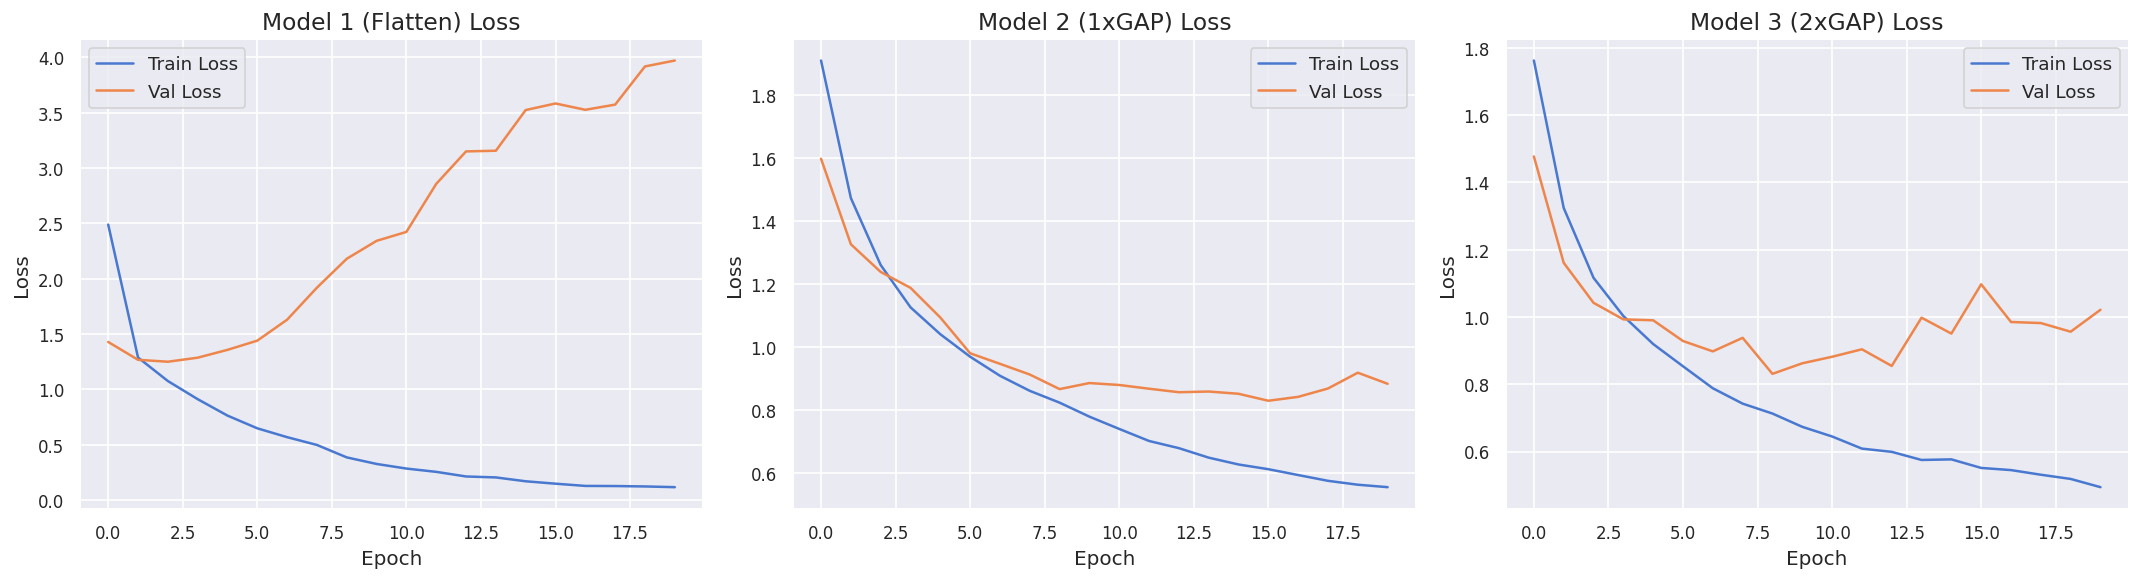

In [ ]:
# ── Part C – Training / Validation Loss Curves ───────────────────────────
# Plot side-by-side loss curves (train vs. val) for all three Part-C models
# to inspect overfitting behaviour as depth increases.

# Depth loss Comparison
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
model_names = ['Model 1 (Flatten)', 'Model 2 (1xGAP)', 'Model 3 (2xGAP)']

for i, h in enumerate(history):
    axs[i].plot(h.history['loss'], label='Train Loss')
    axs[i].plot(h.history['val_loss'], label='Val Loss')
    axs[i].set_title(f'{model_names[i]} Loss')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Loss')
    axs[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Part C – Evaluate Test Accuracy ──────────────────────────────────────
# Compute and print the test-set accuracy for each Part-C model.

from sklearn.metrics import accuracy_score

accuracy_scores = []
for i, model in enumerate(partC_models):
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test.flatten(), y_pred)
    accuracy_scores.append(accuracy)
    print(f"Model {i+1} Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Model 1 Accuracy: 0.5494
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Model 2 Accuracy: 0.7003
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Model 3 Accuracy: 0.6871


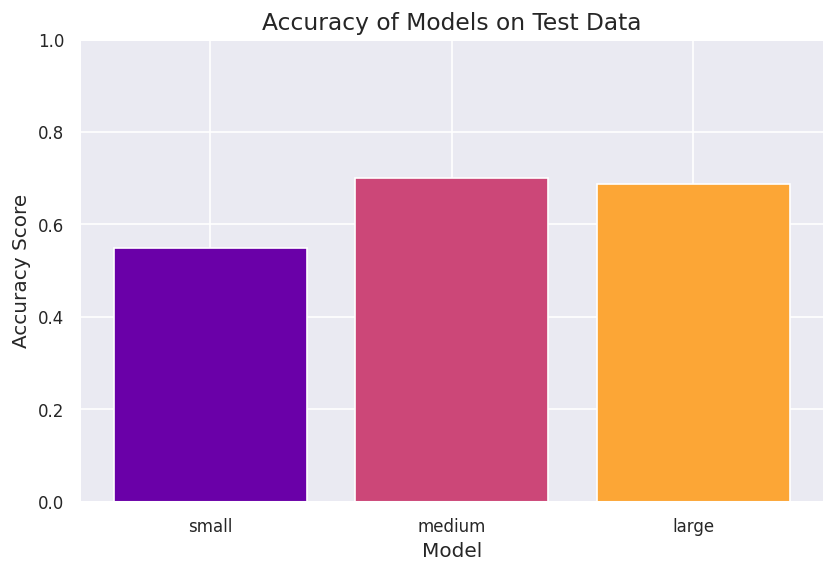

In [ ]:
# ── Part C – Visualise Accuracy Comparison ───────────────────────────────
# Bar chart comparing the test accuracy of the three depth/pooling variants.

# Create the bar plot with different colors
plt.figure(figsize=(8, 5))
plt.bar(name_models, accuracy_scores, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(name_models))))
plt.title('Accuracy of Models on Test Data')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()

# Task 3 -> Regularization

### Part A

In [ ]:
# No dropout (D0)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc = history.history['accuracy'][29]
val_acc = history.history['val_accuracy'][29]
gap = train_acc - val_acc
_, test_acc = model.evaluate(x_test, y_test, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_92 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4223 - loss: 3.6790 - val_accuracy: 0.5275 - val_loss: 1.3582
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5751 - loss: 1.1998 - val_accuracy: 0.5718 - val_loss: 1.2339
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6549 - loss: 0.9856 - val_accuracy: 0.5856 - val_loss: 1.2093
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7136 - loss: 0.8202 - val_accuracy: 0.5677 - val_loss: 1.3249
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7554 - loss: 0.6930 - val_accuracy: 0.5753 - val_loss: 1.3889
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7935 - loss: 0.5923 - val_accuracy: 0.5684 - val_loss: 1.5425
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8307 - loss: 0.4866 - val_accuracy: 0.5406 - val_loss: 1.8878
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8612 - loss: 0.4013 - va

In [ ]:
# After maxpool, rate = 0.25  (D1)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dropout(0.25),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_025 = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc_025 = history_025.history['accuracy'][29]
val_acc_025 = history_025.history['val_accuracy'][29]
gap_025 = train_acc_025 - val_acc_025
_, test_acc_025 = model.evaluate(x_test, y_test, verbose=0)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_96 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1548 - loss: 3.3285 - val_accuracy: 0.2401 - val_loss: 2.0393
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3247 - loss: 1.8516 - val_accuracy: 0.4249 - val_loss: 1.6124
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4445 - loss: 1.5331 - val_accuracy: 0.5063 - val_loss: 1.3689
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5218 - loss: 1.3309 - val_accuracy: 0.5646 - val_loss: 1.2253
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5753 - loss: 1.1891 - val_accuracy: 0.5899 - val_loss: 1.1514
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6204 - loss: 1.0668 - val_accuracy: 0.6087 - val_loss: 1.1045
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6502 - loss: 0.9804 - val_accuracy: 0.6250 - val_loss: 1.0741
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6824 - loss: 0.8915 - va

In [ ]:
# After maxpool, rate = 0.5  (D2)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),
    Dropout(0.5),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dropout(0.5),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_05 = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc_05 = history_05.history['accuracy'][29]
val_acc_05 = history_05.history['val_accuracy'][29]
gap_05 = train_acc_05 - val_acc_05
_, test_acc_05 = model.evaluate(x_test, y_test, verbose=0)

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_100 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.1261 - loss: 3.2722 - val_accuracy: 0.2449 - val_loss: 2.0157
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3458 - loss: 1.7989 - val_accuracy: 0.4035 - val_loss: 1.6344
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4202 - loss: 1.5908 - val_accuracy: 0.4631 - val_loss: 1.4829
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4726 - loss: 1.4578 - val_accuracy: 0.5112 - val_loss: 1.3684
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5123 - loss: 1.3501 - val_accuracy: 0.5615 - val_loss: 1.2387
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5543 - loss: 1.2427 - val_accuracy: 0.5865 - val_loss: 1.1612
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5856 - loss: 1.1622 - val_accuracy: 0.6203 - val_loss: 1.0894
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6122 - loss: 1.0839 - va

In [ ]:
data = {"Train Acc" : [history.history['accuracy'][-1], history_025.history['accuracy'][-1], history_05.history['accuracy'][-1]],
        "Val Acc"   : [history.history['val_accuracy'][-1], history_025.history['val_accuracy'][-1], history_05.history['val_accuracy'][-1]],
        "Test Acc"  : [test_acc, test_acc_025, test_acc_05],
        "Overfit Gap": [gap, gap_025, gap_05]}
index = ["D0", "D1", "D2"]
df = pd.DataFrame(data, index=index)
df

,Train Acc,Val Acc,Test Acc,Overfit Gap
D0,0.978300,0.5593,0.5613,0.419000
D1,0.944925,0.6413,0.6414,0.303625
D2,0.874500,0.6959,0.6852,0.178600


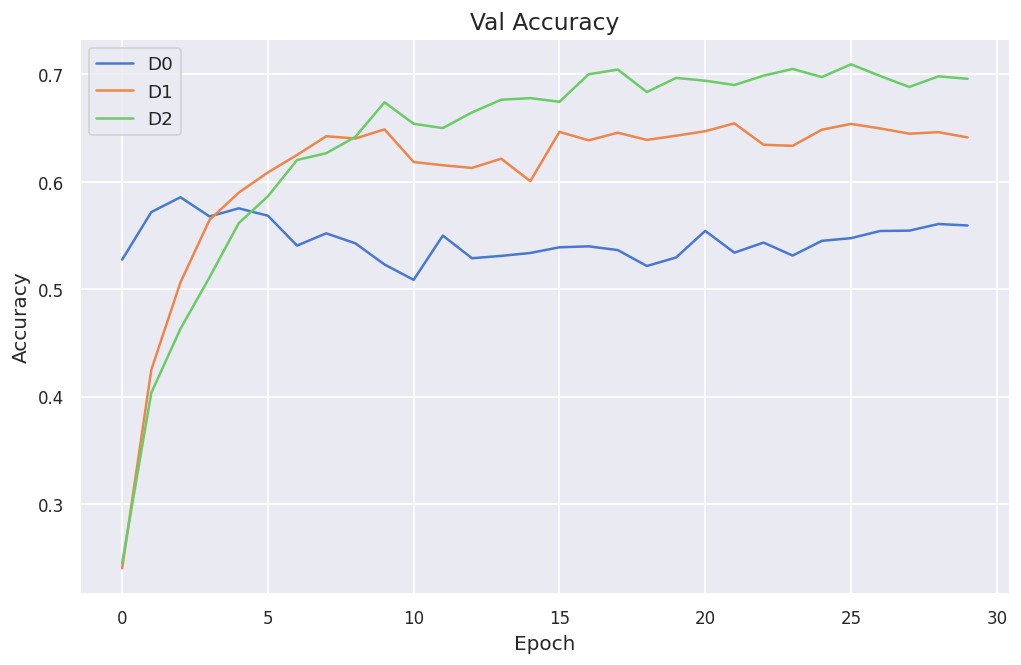

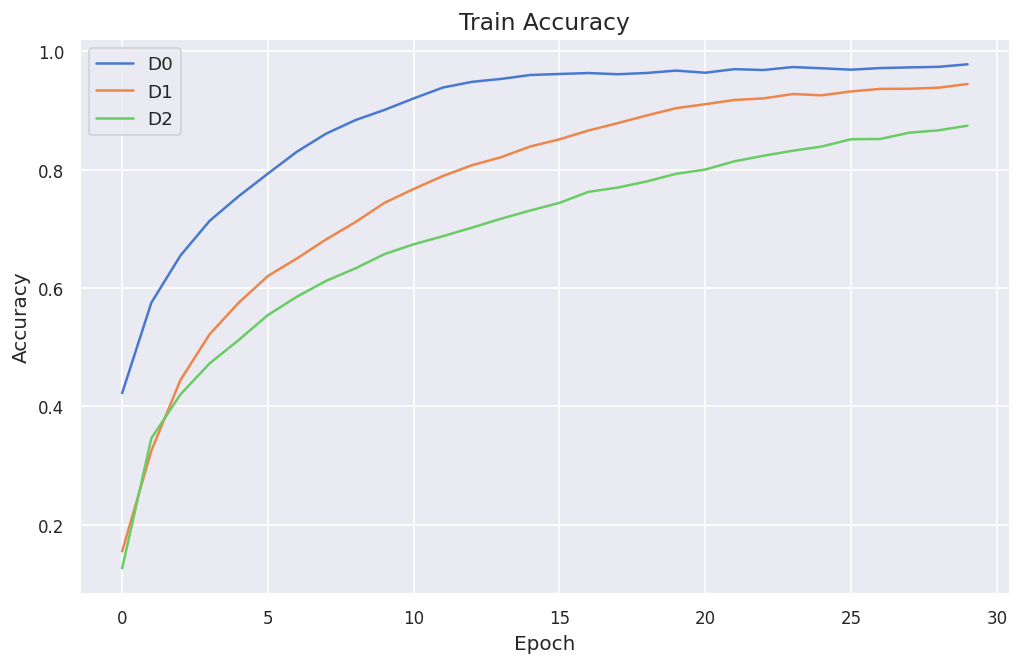

In [ ]:
histories = [history, history_025, history_05]
labels = ['D0', 'D1', 'D2']
plot_curves(histories, labels, title='Val Accuracy', ylabel='Accuracy')
plot_curves(histories, labels,metric = 'accuracy', title='Train Accuracy', ylabel='Accuracy')

In [ ]:
min_gap = min([gap, gap_025, gap_05])
if min_gap == gap:
  print("D0 is best")
elif min_gap == gap_025:
  print("D1 is best")
else:
  print("D2 is best")

D2 is best


### Part B

In [ ]:
# ES0 No early stopping
start = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val))
_, test_acc = model.evaluate(x_test, y_test, verbose=0)
elapsed = time.time() - start

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_104 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4187 - loss: 2.1480 - val_accuracy: 0.5234 - val_loss: 1.3228
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5829 - loss: 1.1695 - val_accuracy: 0.5913 - val_loss: 1.1864
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6735 - loss: 0.9317 - val_accuracy: 0.5805 - val_loss: 1.2432
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7434 - loss: 0.7333 - val_accuracy: 0.5800 - val_loss: 1.3094
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7974 - loss: 0.5821 - val_accuracy: 0.5663 - val_loss: 1.6882
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8383 - loss: 0.4650 - val_accuracy: 0.5561 - val_loss: 1.8837
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8666 - loss: 0.3866 - val_accuracy: 0.5227 - val_loss: 2.0827
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8960 - loss: 0.3053 - va

In [ ]:
# ES2
start_es2 = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])
es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_es2 = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val), callbacks=[es])
_, test_acc_es2 = model.evaluate(x_test, y_test, verbose=0)
elapsed_es2 = time.time() - start_es2

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_108 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.3950 - loss: 2.9022 - val_accuracy: 0.4616 - val_loss: 1.5213
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5536 - loss: 1.2546 - val_accuracy: 0.5511 - val_loss: 1.2849
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6432 - loss: 1.0204 - val_accuracy: 0.5812 - val_loss: 1.2221
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6991 - loss: 0.8632 - val_accuracy: 0.5926 - val_loss: 1.2988
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7402 - loss: 0.7453 - val_accuracy: 0.5724 - val_loss: 1.3746
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7863 - loss: 0.6112 - val_accuracy: 0.5328 - val_loss: 1.6359
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8297 - loss: 0.4952 - val_accuracy: 0.5538 - val_loss: 1.6997
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8645 - loss: 0.3944 - va

In [ ]:
# ES3
start_es3 = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])
es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights = True)
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_es3 = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val), callbacks = [es])
_, test_acc_es3 = model.evaluate(x_test, y_test, verbose=0)
elapsed_es3 = time.time() - start_es3

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_112 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.3661 - loss: 2.6409 - val_accuracy: 0.4628 - val_loss: 1.4813
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5171 - loss: 1.3569 - val_accuracy: 0.5287 - val_loss: 1.3233
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6058 - loss: 1.1162 - val_accuracy: 0.5581 - val_loss: 1.2728
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6673 - loss: 0.9429 - val_accuracy: 0.5409 - val_loss: 1.3841
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7282 - loss: 0.7776 - val_accuracy: 0.5442 - val_loss: 1.4711
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7671 - loss: 0.6670 - val_accuracy: 0.5666 - val_loss: 1.5980
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8114 - loss: 0.5415 - val_accuracy: 0.5443 - val_loss: 1.9242
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8436 - loss: 0.4503 - va

In [ ]:
loss_es0 = []
for i in history.history['val_loss']:
  loss_es0.append(i)
min_es0 = min(loss_es0)

loss_es2 = []
for i in history_es2.history['val_loss']:
  loss_es2.append(i)
min_es2 = min(loss_es2)

loss_es3 = []
for i in history_es3.history['val_loss']:
  loss_es3.append(i)
min_es3 = min(loss_es3)

In [ ]:
import pandas as pd
data = {"Stopped at epoch": [len(history.history['loss']), len(history_es2.history['loss']), len(history_es3.history['loss'])],
        "Best Val loss"   : [min_es0, min_es2, min_es3],
        "Test_Acc"        : [test_acc, test_acc_es2, test_acc_es3],
        "Time(s)"         : [elapsed, elapsed_es2, elapsed_es3]}
index = ["ES0", "ES2", "ES3"]
df = pd.DataFrame(data, index=index)
df


,Stopped at epoch,Best Val loss,Test_Acc,Time(s)
ES0,50,1.186365,0.5805,209.271572
ES2,8,1.222105,0.5741,42.866542
ES3,13,1.272793,0.5645,61.844786


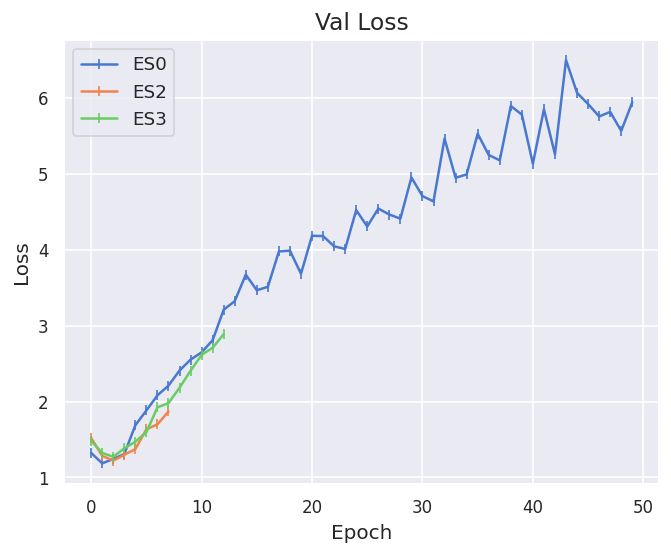

In [ ]:
histories = [history, history_es2, history_es3]
labels = ['ES0', 'ES2', 'ES3']
# plot_curves(histories, labels, metric = 'val_loss', title='Val Loss', ylabel='Accuracy')
plt.plot(history.history['val_loss'], label='ES0', marker = '|')
plt.plot(history_es2.history['val_loss'], label='ES2', marker = '|')
plt.plot(history_es3.history['val_loss'], label='ES3', marker = '|')
plt.title('Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print("From the results:")
print("patience=5 is really aggresive as it stops too early")
print("patience=10 is not too lenient,as it doesn't stop too late")

From the results:
patience=5 is really aggresive as it stops too early
patience=10 is not too lenient,as it doesn't stop too late


# **Task4 -> Optimizers**
### Part A



In [ ]:
# ── Part D – Optimizer Experiment (Setup) ────────────────────────────────
# Define a dictionary of optimizers to compare:
# SGD, SGD+Momentum, AdaGrad, RMSProp, and Adam — all at the same LR.

# Define optimizer factories to avoid reusing optimizer objects across different models
optimizer_factories = {
    'SGD':keras.optimizers.SGD(learning_rate=0.001),
    'Momentum':keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad':keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp':keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':keras.optimizers.Adam(learning_rate=0.001),
}


--- Training with Optimizer: SGD ---
Test Acc: 0.5711 | Test Loss: 1.2349 | Time:79.4s

--- Training with Optimizer: Momentum ---
Test Acc: 0.6485 | Test Loss: 2.8718 | Time:81.3s

--- Training with Optimizer: AdaGrad ---
Test Acc: 0.6570 | Test Loss: 3.2891 | Time:80.9s

--- Training with Optimizer: RMSProp ---
Test Acc: 0.6391 | Test Loss: 4.7828 | Time:84.2s

--- Training with Optimizer: Adam ---
Test Acc: 0.6347 | Test Loss: 4.3605 | Time:85.6s


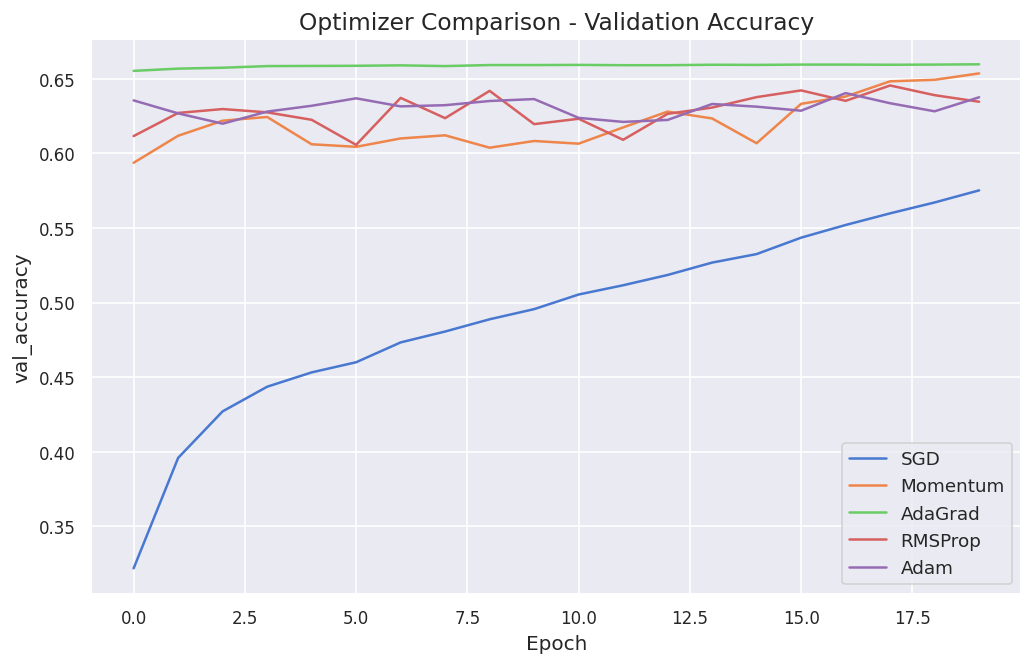

In [ ]:
# ── Part D – Train with Different Optimizers ─────────────────────────────
# Re-build the medium CNN architecture and train one copy per optimizer.
# Results (accuracy, loss, time) are stored for comparison.

medium_model_base = Sequential([
    layers.Input(shape=(32, 32, 3)),
    Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation='softmax')
])

results = {}

for opt_name, optimizer in optimizer_factories.items():
    print(f"\n--- Training with Optimizer: {opt_name} ---")
    model = medium_model_base

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'],
                  )

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train, y_train, x_val, y_val, x_test, y_test,
        epochs=20, batch_size=128
    )
    results[opt_name] = history

# Plot all curves together for comparison
plot_curves(list(results.values()), list(results.keys()), title='Optimizer Comparison - Validation Accuracy')

## Part B

Learning Rate: 0.0001 for Adam optimizer
Test Acc: 0.6570 | Test Loss: 4.9084 | Time:122.6s
Learning Rate: 0.001 for Adam optimizer
Test Acc: 0.6289 | Test Loss: 6.2980 | Time:121.3s
Learning Rate: 0.01 for Adam optimizer
Test Acc: 0.1000 | Test Loss: 2.3032 | Time:119.6s


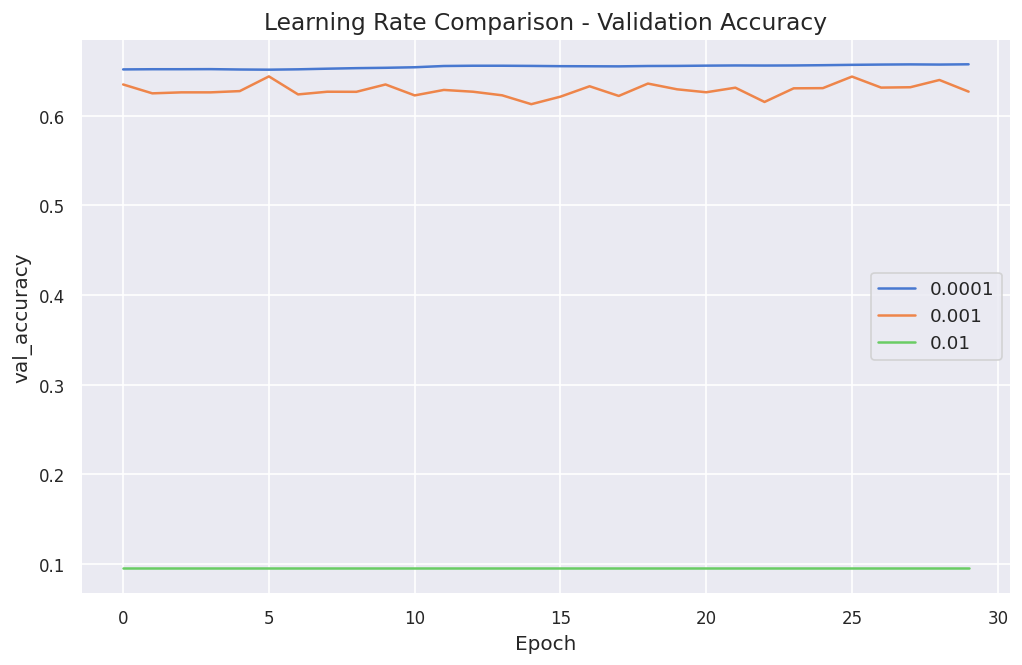

In [ ]:
# ── Part D – Learning-Rate Sweep (Adam) ──────────────────────────────────
# Train the medium CNN with Adam at three learning rates
# (0.0001, 0.001, 0.01) to study the effect on convergence.

learning_rates = [0.0001,0.001,0.01]
results = {}

for i in learning_rates:
  print(f"Learning Rate: {i} for Adam optimizer")
  model = medium_model_base
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=i),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'],
                )

  history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train, y_train, x_val, y_val, x_test, y_test,
        epochs=30, batch_size=128
    )
  results[i] = history

plot_curves(list(results.values()), list(results.keys()), title='Learning Rate Comparison - Validation Accuracy')

## Standardization Setup

In [ ]:
# Compute mean and std from training set ONLY (per channel, shape: (3,))
mean = x_train.mean(axis=(0, 1, 2))   # mean per RGB channel
std  = x_train.std(axis=(0, 1, 2))    # std  per RGB channel

# Apply standardization: x' = (x - mean) / std
x_train_standardized = (x_train - mean) / std
x_val_standardized   = (x_val   - mean) / std
x_test_standardized  = (x_test  - mean) / std

print(f"Mean per channel: {mean}")
print(f"Std  per channel: {std}")
print(f"Train standardized range: [{x_train_standardized.min():.2f}, {x_train_standardized.max():.2f}]")

Mean per channel: [125.32014  122.925385 113.78766 ]
Std  per channel: [63.027916 62.145065 66.73145 ]
Train standardized range: [-1.99, 2.13]


## Data Augmentation Setup

In [ ]:
# Data augmentation generator (same config as Task 1B)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_standardized)
print("Data augmentation generator is ready.")

Data augmentation generator is ready.


---

# Task 5A — Best Model Selection & Evaluation

## Chosen Configuration & Justification

Based on findings from Tasks 1–4 (results obtained by teammates), the following configuration was selected:


In [ ]:
#  Task 5A: Build the Best Model
# Architecture: Medium CNN from Task 2A + Dropout D1 configuration

def build_best_model(input_shape=(32, 32, 3)):
    """
    Best model: Medium CNN (filters 32-32-64-64) with Dropout D1 (rate=0.25).
    Dropout is applied after each MaxPool and before the output Dense layer.
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),     # D1: dropout after MaxPool

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),     # D1: dropout after MaxPool

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.25),     # D1: dropout before output
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


best_model = build_best_model()
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Task 5A: Train the Best Model
# 50 epochs, early stopping with patience=7, data augmentation

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True   # roll back to best epoch weights
)

start_time = time.time()

# Train using the augmentation generator (flows batches with random augmentations)
history_best = best_model.fit(
    datagen.flow(x_train_standardized, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

elapsed_best = time.time() - start_time

# Evaluate on test set
test_loss_best, test_acc_best = best_model.evaluate(
    x_test_standardized, to_categorical(y_test, 10), verbose=0
)

print(f"\n✅ Best Model — Test Accuracy: {test_acc_best:.4f} | Test Loss: {test_loss_best:.4f}")
print(f"   Training time: {elapsed_best:.1f}s | Stopped at epoch: {len(history_best.history['val_loss'])}")

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.3996 - loss: 1.6358 - val_accuracy: 0.5223 - val_loss: 1.3280
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.5366 - loss: 1.2933 - val_accuracy: 0.6334 - val_loss: 1.0320
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.5993 - loss: 1.1333 - val_accuracy: 0.6521 - val_loss: 1.0066
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6374 - loss: 1.0266 - val_accuracy: 0.6847 - val_loss: 0.9102
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6581 - loss: 0.9716 - val_accuracy: 0.6923 - val_loss: 0.8876
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6780 - loss: 0.9076 - val_accuracy: 0.7156 - val_loss: 0.8482
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.6909 - loss: 0.8758 - val_accuracy: 0.7110 - val_loss: 0.8672
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.7039 - loss: 0.8439 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


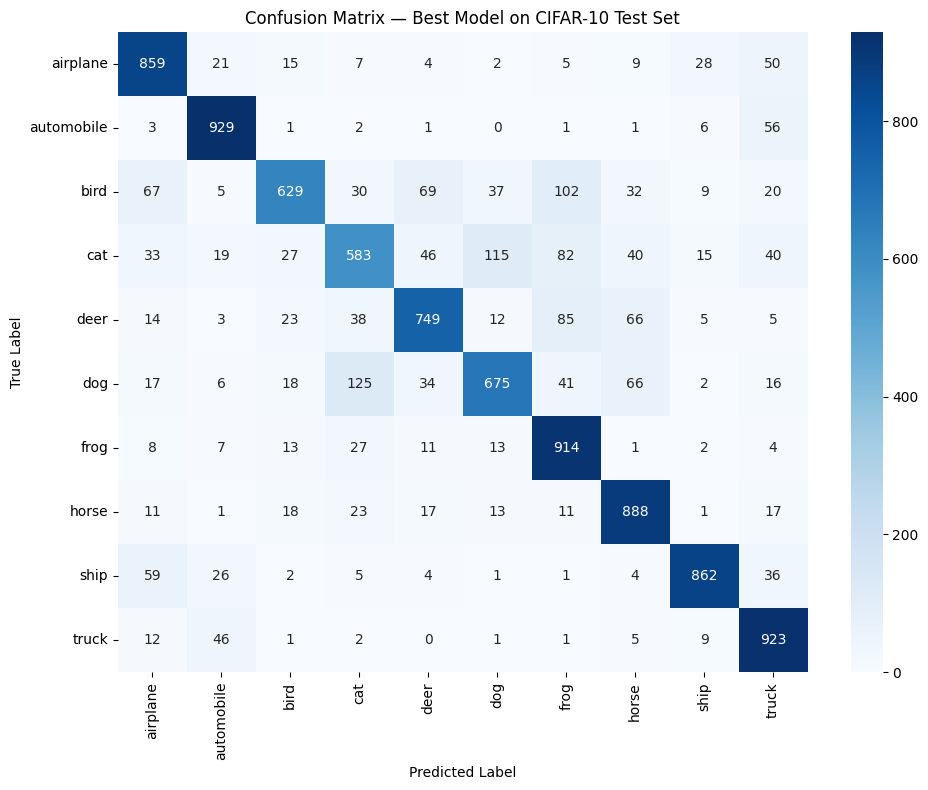


Classification Report:
              precision    recall  f1-score   support

    airplane       0.79      0.86      0.82      1000
  automobile       0.87      0.93      0.90      1000
        bird       0.84      0.63      0.72      1000
         cat       0.69      0.58      0.63      1000
        deer       0.80      0.75      0.77      1000
         dog       0.78      0.68      0.72      1000
        frog       0.74      0.91      0.81      1000
       horse       0.80      0.89      0.84      1000
        ship       0.92      0.86      0.89      1000
       truck       0.79      0.92      0.85      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



In [ ]:
#  Task 5A: Confusion Matrix
# Predict class labels for the entire test set

y_pred_probs = best_model.predict(x_test_standardized)   # shape: (10000, 10)
y_pred       = np.argmax(y_pred_probs, axis=1)            # predicted class index
y_true       = y_test.flatten()                           # true class index

# Build confusion matrix (rows = actual, cols = predicted)
cm = confusion_matrix(y_true, y_pred)

# Plot as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Best Model on CIFAR-10 Test Set')
plt.tight_layout()
plt.show()

# Full classification report (precision, recall, F1 per class)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
#Task 5B

misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")
print(f"Overall accuracy: {(1 - len(misclassified_idx)/len(y_test))*100:.2f}%")

Total misclassified: 1989 / 10000
Overall accuracy: 80.11%


In [ ]:
#  Task 5B  Deliverable 39: 3 Worst-Performing Classes (lowest recall)
# Recall per class = how many true samples of that class were correctly predicted

# Compute per-class recall from the confusion matrix
# recall[i] = cm[i, i] / cm[i, :].sum()  (true positives / all actual positives)
per_class_recall = cm.diagonal() / cm.sum(axis=1)

# Rank classes by recall (ascending = worst first)
worst_class_indices = np.argsort(per_class_recall)[:3]

print("Per-Class Recall:")
for i, recall in enumerate(per_class_recall):
    marker = " ← WORST" if i in worst_class_indices else ""
    print(f"  {CLASS_NAMES[i]:12s}: {recall:.4f}{marker}")

print(f"\n3 Worst Classes: {[CLASS_NAMES[i] for i in worst_class_indices]}")

Per-Class Recall:
  airplane    : 0.8590
  automobile  : 0.9290
  bird        : 0.6290 ← WORST
  cat         : 0.5830 ← WORST
  deer        : 0.7490
  dog         : 0.6750 ← WORST
  frog        : 0.9140
  horse       : 0.8880
  ship        : 0.8620
  truck       : 0.9230

3 Worst Classes: ['cat', 'bird', 'dog']


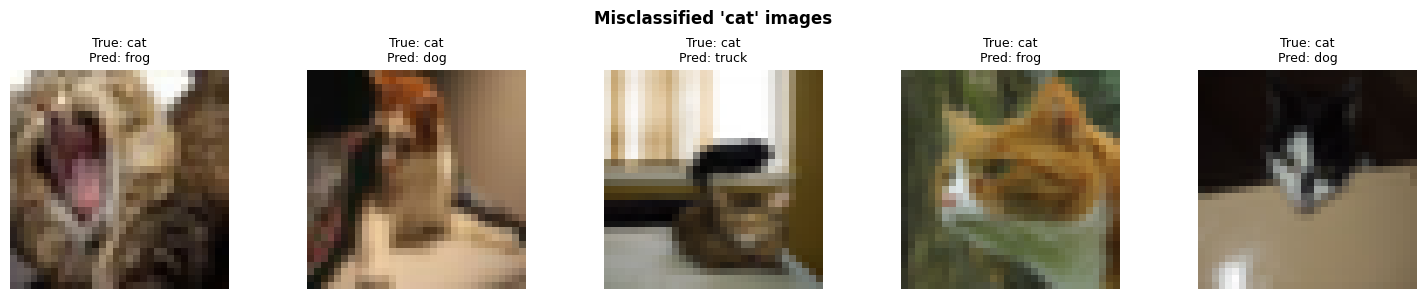

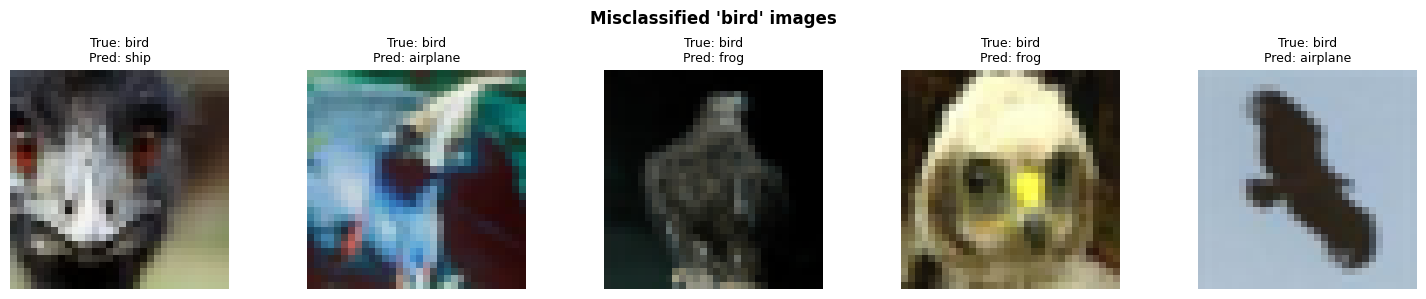

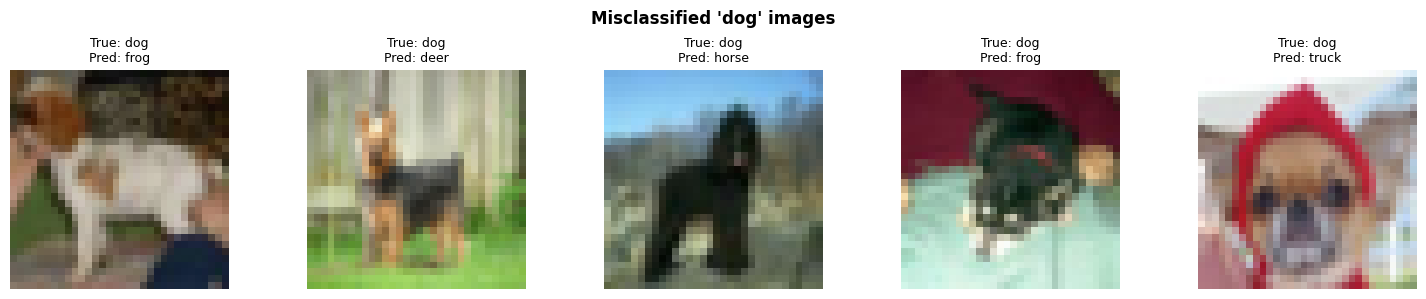

In [ ]:
#  Task 5B  Deliverable 40: Show 5 Misclassified Images per Worst Class

def show_misclassified(true_class_idx, n=5):
    """
    Display n misclassified images for a given true class.
    true_class_idx: integer index (0–9) corresponding to CLASS_NAMES
    """
    # Find test indices where the true label = true_class_idx AND prediction is wrong
    idx = [i for i in misclassified_idx if y_true[i] == true_class_idx][:n]

    if len(idx) == 0:
        print(f"No misclassified samples found for '{CLASS_NAMES[true_class_idx]}'")
        return

    fig, axes = plt.subplots(1, len(idx), figsize=(15, 3))
    for ax, i in zip(axes, idx):
        # x_test holds the raw (un-standardized) pixels for display
        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(
            f"True: {CLASS_NAMES[y_true[i]]}\nPred: {CLASS_NAMES[y_pred[i]]}",
            fontsize=9
        )
        ax.axis('off')

    plt.suptitle(
        f"Misclassified '{CLASS_NAMES[true_class_idx]}' images",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# Show 5 misclassified images for each of the 3 worst classes
for class_idx in worst_class_indices:
    show_misclassified(class_idx, n=5)

In [ ]:
#  Task 5B  Deliverable 41: Top 3 Most Confused Class Pairs
# A confusion pair (A → B) means: model predicted B when true label was A
# We look at off-diagonal entries of the confusion matrix

# Set diagonal to 0 so we only see errors
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# Flatten and find top 3 off-diagonal entries
flat_indices = np.argsort(cm_errors.flatten())[::-1][:3]
top_confused_pairs = [(idx // 10, idx % 10) for idx in flat_indices]

print("Top 3 Most Confused Class Pairs (True → Predicted):")
for true_c, pred_c in top_confused_pairs:
    count = cm_errors[true_c, pred_c]
    print(f"  {CLASS_NAMES[true_c]:12s} → {CLASS_NAMES[pred_c]:12s}  ({count} times)")

Top 3 Most Confused Class Pairs (True → Predicted):
  dog          → cat           (125 times)
  cat          → dog           (115 times)
  bird         → frog          (102 times)


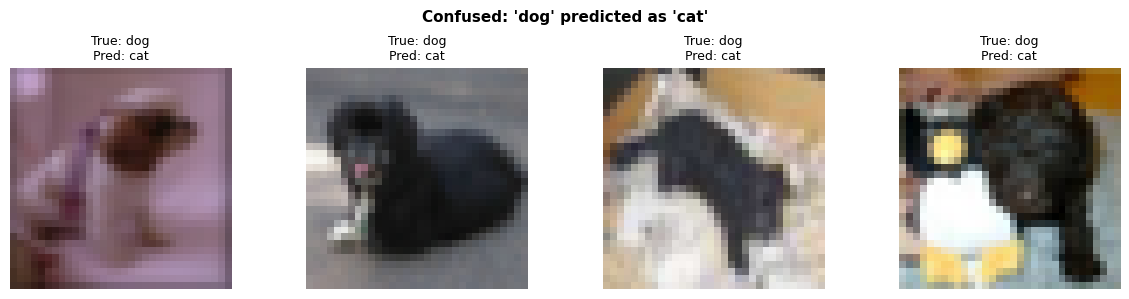

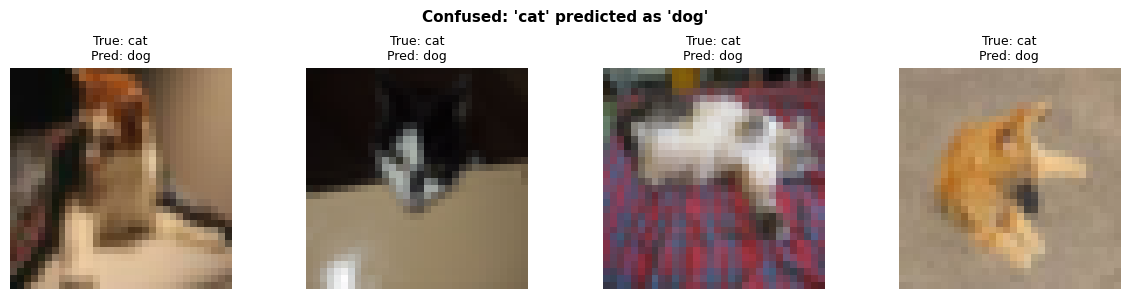

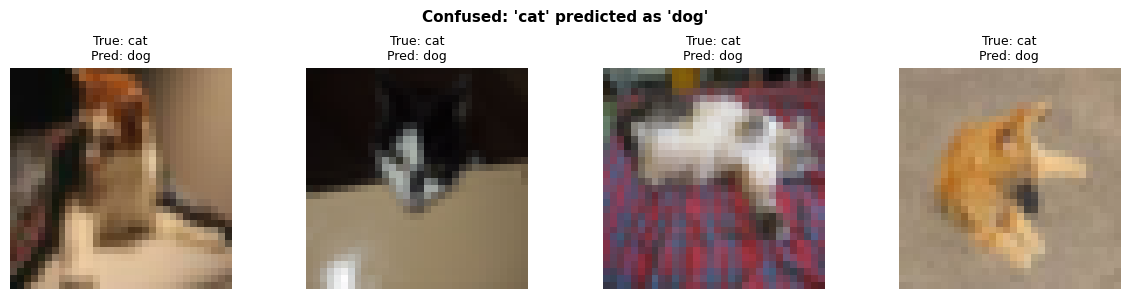

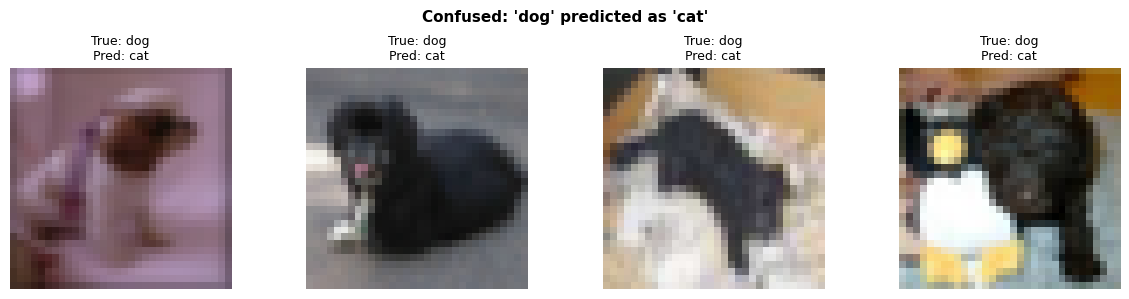

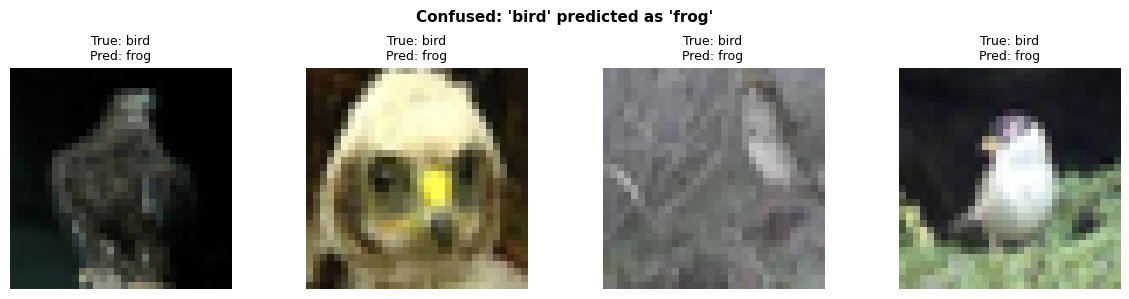

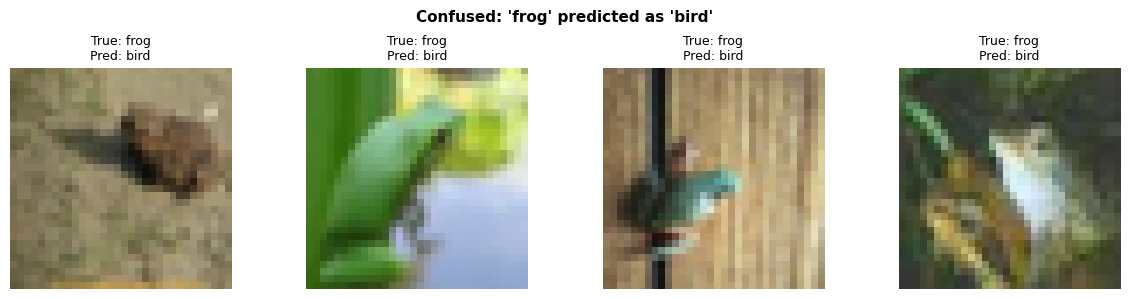

In [ ]:
# ─ Task 5B  Deliverable 41 (cont.): Show 4 Examples per Confusion Direction
# For each confused pair (A, B), show: A predicted as B, AND B predicted as A

def show_confused_pair(true_c, pred_c, n=4):
    """
    Display n examples where true_c was predicted as pred_c.
    """
    idx = [
        i for i in misclassified_idx
        if y_true[i] == true_c and y_pred[i] == pred_c
    ][:n]

    if len(idx) == 0:
        print(f"No samples: {CLASS_NAMES[true_c]} → {CLASS_NAMES[pred_c]}")
        return

    fig, axes = plt.subplots(1, len(idx), figsize=(12, 3))
    # Handle edge case where only 1 sample found
    if len(idx) == 1:
        axes = [axes]
    for ax, i in zip(axes, idx):
        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(
            f"True: {CLASS_NAMES[true_c]}\nPred: {CLASS_NAMES[pred_c]}",
            fontsize=9
        )
        ax.axis('off')
    plt.suptitle(
        f"Confused: '{CLASS_NAMES[true_c]}' predicted as '{CLASS_NAMES[pred_c]}'",
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# For each top confused pair, show BOTH directions
for true_c, pred_c in top_confused_pairs:
    show_confused_pair(true_c, pred_c, n=4)   # Direction A → B
    show_confused_pair(pred_c, true_c, n=4)   # Direction B → A

In [ ]:
#  Task 6A: Step 1 — Resize CIFAR-10 Images to 48×48 for VGG16
# VGG16 expects at minimum 48×48 input; CIFAR-10 is 32×32

print("Resizing images to 48×48 (this may take a moment)...")

x_train_resized = tf.image.resize(x_train_standardized, (48, 48)).numpy()
x_val_resized   = tf.image.resize(x_val_standardized,   (48, 48)).numpy()
x_test_resized  = tf.image.resize(x_test_standardized,  (48, 48)).numpy()

print(f"Resized train shape: {x_train_resized.shape}")
print(f"Resized val   shape: {x_val_resized.shape}")
print(f"Resized test  shape: {x_test_resized.shape}")

Resizing images to 48×48 (this may take a moment)...
Resized train shape: (40000, 48, 48, 3)
Resized val   shape: (10000, 48, 48, 3)
Resized test  shape: (10000, 48, 48, 3)


In [ ]:
#  Task 6A  Model 1: From Scratch (Medium CNN, input 48×48)
# Same architecture as Task 2A Medium model, but with larger input shape

def build_medium_cnn(input_shape=(48, 48, 3)):
    """Medium CNN from Task 2A — filters: 32, 32, 64, 64."""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("=" * 60)
print("Model 1: From Scratch")
print("=" * 60)
model_scratch = build_medium_cnn(input_shape=(48, 48, 3))
model_scratch.summary()

history_scratch, acc_scratch, loss_scratch, time_scratch = train_and_evaluate(
    model_scratch,
    x_train_resized, y_train,
    x_val_resized,   y_val,
    x_test_resized,  y_test,
    epochs=20, batch_size=128
)

Model 1: From Scratch


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,690 (9.26 MB)

 Trainable params: 2,427,690 (9.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5054 - loss: 1.3900 - val_accuracy: 0.6141 - val_loss: 1.0906
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6739 - loss: 0.9329 - val_accuracy: 0.6714 - val_loss: 0.9527
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7496 - loss: 0.7170 - val_accuracy: 0.6873 - val_loss: 0.9277
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8119 - loss: 0.5449 - val_accuracy: 0.6847 - val_loss: 1.0266
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8493 - loss: 0.4322 - val_accuracy: 0.6548 - val_loss: 1.1595
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8884 - loss: 0.3185 - val_accuracy: 0.6590 - val_loss: 1.2876
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9222 - loss: 0.2225 - val_accuracy: 0.6643 - val_loss: 1.4965
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9451 - loss: 0.1580 - val_acc

In [ ]:
#  Task 6A — Model 2: Feature Extraction (Frozen VGG16)
# Load VGG16 pre-trained on ImageNet, freeze ALL layers, add custom head

def build_feature_extraction_model(input_shape=(48, 48, 3)):
    """
    Feature Extraction: VGG16 base (fully frozen) + custom classification head.
    The VGG16 base acts as a fixed feature extractor — its weights never change.
    """
    # Load VGG16 without top classification layers (include_top=False)
    vgg_base = keras.applications.VGG16(
        weights='imagenet',      # load ImageNet pre-trained weights
        include_top=False,       # exclude the final Dense layers
        input_shape=input_shape
    )

    # Freeze ALL VGG16 layers — weights will NOT update during training
    vgg_base.trainable = False

    # Build the full model: frozen VGG16 + custom head
    model = models.Sequential([
        vgg_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("=" * 60)
print("Model 2: Feature Extraction (Frozen VGG16)")
print("=" * 60)
model_fe = build_feature_extraction_model()
model_fe.summary()   # Note: trainable vs non-trainable params

history_fe, acc_fe, loss_fe, time_fe = train_and_evaluate(
    model_fe,
    x_train_resized, y_train,
    x_val_resized,   y_val,
    x_test_resized,  y_test,
    epochs=20, batch_size=128
)

Model 2: Feature Extraction (Frozen VGG16)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.5319 - loss: 1.3462 - val_accuracy: 0.6415 - val_loss: 1.0395
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6340 - loss: 1.0603 - val_accuracy: 0.6656 - val_loss: 0.9649
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6588 - loss: 0.9876 - val_accuracy: 0.6770 - val_loss: 0.9350
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6744 - loss: 0.9395 - val_accuracy: 0.6816 - val_loss: 0.9215
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.6849 - loss: 0.9039 - val_accuracy: 0.6906 - val_loss: 0.9015
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6962 - loss: 0.8769 - val_accuracy: 0.6915 - val_loss: 0.8947
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.7054 - loss: 0.8484 - val_accuracy: 0.6964 - val_loss: 0.8891
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.7139 - loss: 0.8269 - 

In [ ]:
# *- Task 6A — Model 3: Fine-Tuning (Unfreeze last 4 VGG16 layers, lr=1e-5)
# Using a very low LR to avoid destroying pre-trained ImageNet weights

def build_finetune_model(learning_rate=1e-5, input_shape=(48, 48, 3)):
    """
    Fine-Tuning: VGG16 base with last 4 layers unfrozen.
    The last 4 VGG16 layers are allowed to adapt to CIFAR-10.
    Low LR (1e-5) prevents catastrophic forgetting of ImageNet features.
    """
    vgg_base = keras.applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # First, freeze ALL VGG16 layers
    vgg_base.trainable = False

    # Then, unfreeze ONLY the last 4 layers
    for layer in vgg_base.layers[-4:]:
        layer.trainable = True

    # Verify which layers are trainable
    print("VGG16 layer trainability (last 6 layers):")
    for layer in vgg_base.layers[-6:]:
        print(f"  {layer.name:20s} trainable={layer.trainable}")

    # Same classification head as Model 2
    model = models.Sequential([
        vgg_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("=" * 60)
print("Model 3: Fine-Tuning (lr=1e-5)")
print("=" * 60)
model_ft_low = build_finetune_model(learning_rate=1e-5)
model_ft_low.summary()   # Note trainable vs non-trainable params

history_ft_low, acc_ft_low, loss_ft_low, time_ft_low = train_and_evaluate(
    model_ft_low,
    x_train_resized, y_train,
    x_val_resized,   y_val,
    x_test_resized,  y_test,
    epochs=20, batch_size=128
)

Model 3: Fine-Tuning (lr=1e-5)
VGG16 layer trainability (last 6 layers):
  block4_conv3         trainable=False
  block4_pool          trainable=False
  block5_conv1         trainable=True
  block5_conv2         trainable=True
  block5_conv3         trainable=True
  block5_pool          trainable=True


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.4163 - loss: 1.6464 - val_accuracy: 0.6767 - val_loss: 0.9635
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.6526 - loss: 1.0103 - val_accuracy: 0.7345 - val_loss: 0.7837
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.7111 - loss: 0.8461 - val_accuracy: 0.7589 - val_loss: 0.7069
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.7445 - loss: 0.7504 - val_accuracy: 0.7729 - val_loss: 0.6590
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7692 - loss: 0.6790 - val_accuracy: 0.7865 - val_loss: 0.6229
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7858 - loss: 0.6305 - val_accuracy: 0.7932 - val_loss: 0.5996
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8034 - loss: 0.5774 - val_accuracy: 0.7996 - val_loss: 0.5794
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.8179 - loss: 0.5402 - 

In [ ]:
#  Task 6A — Model 4: Fine-Tuning (Higher LR = 0.001)
# Same architecture as Model 3 (last 4 unfrozen) but with lr=0.001
# This tests whether a high LR destroys the pre-trained weights

print("=" * 60)
print("Model 4: Fine-Tuning (lr=0.001) — High LR Test")
print("=" * 60)
model_ft_high = build_finetune_model(learning_rate=0.001)
# No need to print summary again — same architecture as Model 3

history_ft_high, acc_ft_high, loss_ft_high, time_ft_high = train_and_evaluate(
    model_ft_high,
    x_train_resized, y_train,
    x_val_resized,   y_val,
    x_test_resized,  y_test,
    epochs=20, batch_size=128
)

Model 4: Fine-Tuning (lr=0.001) — High LR Test
VGG16 layer trainability (last 6 layers):
  block4_conv3         trainable=False
  block4_pool          trainable=False
  block5_conv1         trainable=True
  block5_conv2         trainable=True
  block5_conv3         trainable=True
  block5_pool          trainable=True
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.0990 - loss: 2.3086 - val_accuracy: 0.0977 - val_loss: 2.3027
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.1000 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.0995 - loss: 2.3028 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.0972 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.0996 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 6/20
313/313 ━━━━━━━━━━━━

In [ ]:
#  Task 6A — Deliverable 44: Trainable vs Non-Trainable Params Summary

def count_params(model):
    """Return (trainable_params, non_trainable_params) for a model."""
    trainable     = sum(np.prod(v.shape) for v in model.trainable_weights)
    non_trainable = sum(np.prod(v.shape) for v in model.non_trainable_weights)
    return int(trainable), int(non_trainable)


# Collect results for the summary table
results = [
    ("From Scratch",         model_scratch, 0,            acc_scratch,  time_scratch),
    ("Feature Extraction",   model_fe,      0,            acc_fe,       time_fe),
    ("Fine-Tune (lr=1e-5)",  model_ft_low,  0,            acc_ft_low,   time_ft_low),
    ("Fine-Tune (lr=1e-3)",  model_ft_high, 0,            acc_ft_high,  time_ft_high),
]

print(f"{'Model':<25} {'Trainable':>12} {'Non-Trainable':>15} {'Test Acc':>10} {'Time (s)':>10}")
print("-" * 75)
for name, model, _, acc, t in results:
    tr, non_tr = count_params(model)
    print(f"{name:<25} {tr:>12,} {non_tr:>15,} {acc:>10.4f} {t:>10.1f}")

Model                        Trainable   Non-Trainable   Test Acc   Time (s)
---------------------------------------------------------------------------
From Scratch                 2,427,690               0     0.6706      151.5
Feature Extraction             133,898      14,714,688     0.6913      393.6
Fine-Tune (lr=1e-5)          7,213,322       7,635,264     0.8226      450.8
Fine-Tune (lr=1e-3)          7,213,322       7,635,264     0.1000      440.8


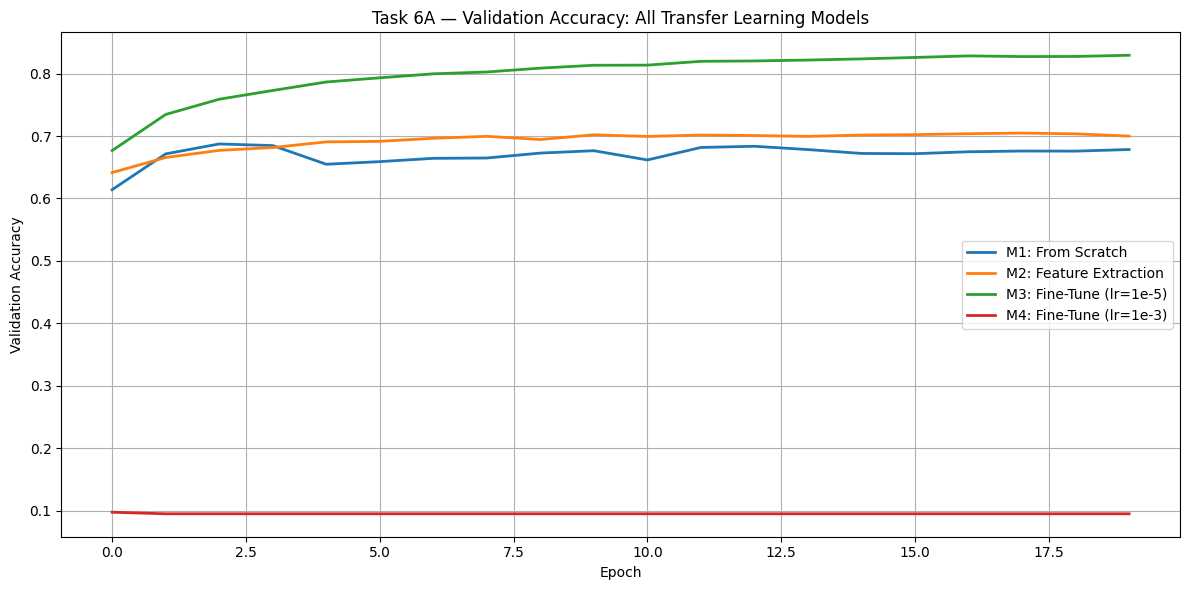

In [ ]:
#  Task 6A — Deliverable 46: Validation Accuracy Curves — All 4 Models

plt.figure(figsize=(12, 6))
plt.plot(history_scratch.history['val_accuracy'],  label='M1: From Scratch',        linewidth=2)
plt.plot(history_fe.history['val_accuracy'],       label='M2: Feature Extraction',  linewidth=2)
plt.plot(history_ft_low.history['val_accuracy'],   label='M3: Fine-Tune (lr=1e-5)', linewidth=2)
plt.plot(history_ft_high.history['val_accuracy'],  label='M4: Fine-Tune (lr=1e-3)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Task 6A — Validation Accuracy: All Transfer Learning Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

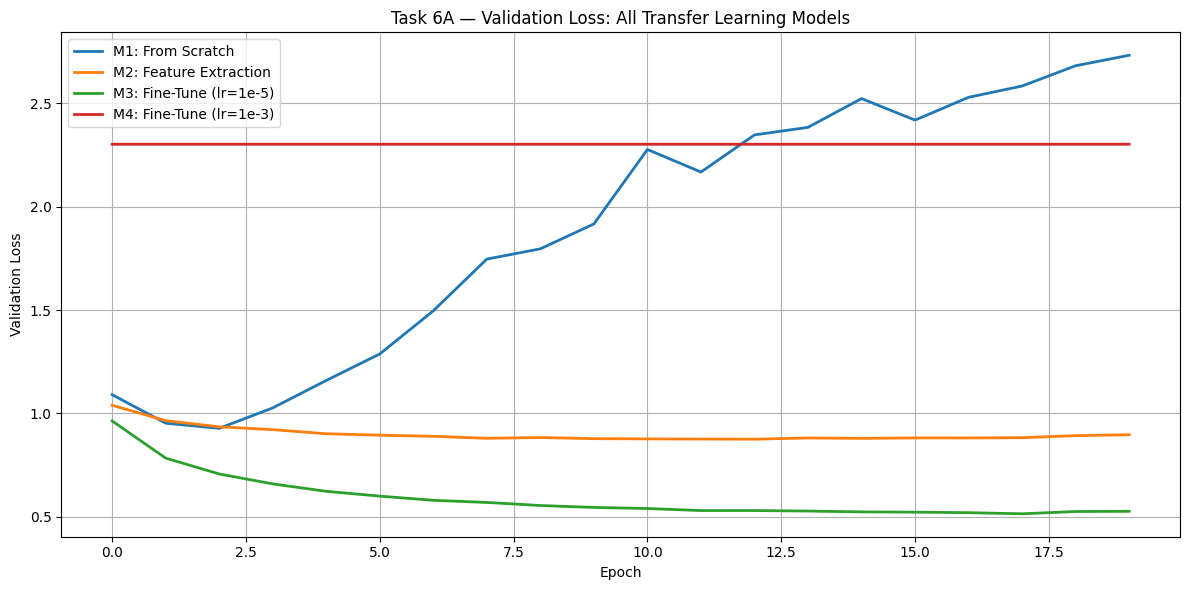

In [ ]:
#  Task 6A — Deliverable 47: Validation Loss Curves — All 4 Models

plt.figure(figsize=(12, 6))
plt.plot(history_scratch.history['val_loss'],  label='M1: From Scratch',        linewidth=2)
plt.plot(history_fe.history['val_loss'],       label='M2: Feature Extraction',  linewidth=2)
plt.plot(history_ft_low.history['val_loss'],   label='M3: Fine-Tune (lr=1e-5)', linewidth=2)
plt.plot(history_ft_high.history['val_loss'],  label='M4: Fine-Tune (lr=1e-3)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Task 6A — Validation Loss: All Transfer Learning Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()